In [2]:
import os
import cv2
import numpy as np
import mediapipe as mp
from tqdm import tqdm

In [3]:
VIDEO_PATH = r"C:\Users\Visla\Downloads\s1"

videos = []

for root, dirs, files in os.walk(VIDEO_PATH):

    for file in files:

        if file.endswith(".mpg"):

            videos.append(
                os.path.join(root, file)
            )

print("Total Videos:", len(videos))

Total Videos: 1000


In [4]:
mp_face_mesh = mp.solutions.face_mesh

LIPS = [
    61,146,91,181,84,17,314,
    405,321,375,291,308,
    324,318,402,317,14,
    87,178,88,95
]

In [5]:
def extract_mouth(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    with mp_face_mesh.FaceMesh(
        static_image_mode=False,
        max_num_faces=1,
        refine_landmarks=True
    ) as face_mesh:

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            result = face_mesh.process(rgb)

            if result.multi_face_landmarks:

                h, w, _ = frame.shape

                landmarks = result.multi_face_landmarks[0]

                xs = []
                ys = []

                for idx in LIPS:

                    x = int(
                        landmarks.landmark[idx].x * w
                    )

                    y = int(
                        landmarks.landmark[idx].y * h
                    )

                    xs.append(x)
                    ys.append(y)

                x1 = max(0, min(xs)-20)
                y1 = max(0, min(ys)-20)

                x2 = min(w, max(xs)+20)
                y2 = min(h, max(ys)+20)

                mouth = frame[
                    y1:y2,
                    x1:x2
                ]

                mouth = cv2.cvtColor(
                    mouth,
                    cv2.COLOR_BGR2GRAY
                )

                mouth = cv2.equalizeHist(
                    mouth
                )

                mouth = cv2.resize(
                    mouth,
                    (128,64)
                )

                mouth = mouth / 255.0

                frames.append(
                    mouth[..., np.newaxis]
                )

    cap.release()

    return np.array(frames)

In [6]:
sample = extract_mouth(
    videos[0]
)

print(sample.shape)

C:\Users\Visla\anaconda3\envs\lipread\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(75, 64, 128, 1)


In [7]:
print(sample.shape)

(75, 64, 128, 1)


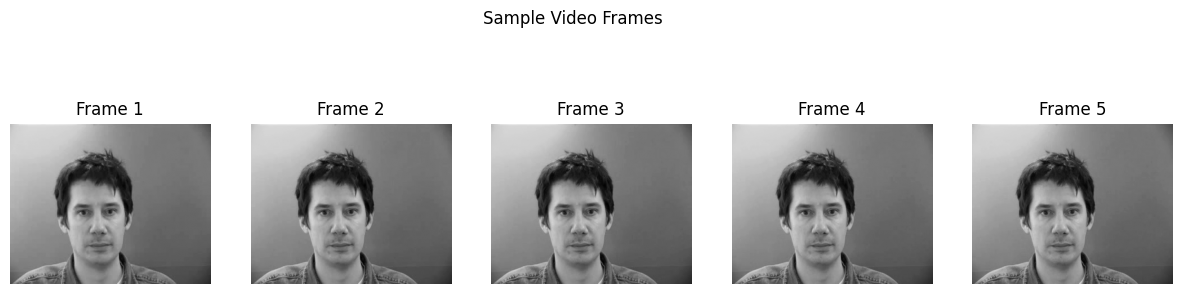

In [121]:
import cv2
import matplotlib.pyplot as plt

video_path = r"C:\Users\Visla\Downloads\s1\bbaf2n.mpg"

cap = cv2.VideoCapture(video_path)

frames = []

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    frames.append(gray)

cap.release()

plt.figure(figsize=(15,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        frames[i],
        cmap="gray"
    )

    plt.axis("off")

    plt.title(f"Frame {i+1}")

plt.suptitle("Sample Video Frames")

plt.show()

In [8]:
MAX_FRAMES = 75

X = []
video_names = []

In [9]:
for video_path in tqdm(videos):

    try:

        frames = extract_mouth(video_path)

        if len(frames) == 0:
            continue

        if len(frames) < MAX_FRAMES:

            pad = np.zeros(
                (
                    MAX_FRAMES - len(frames),
                    64,
                    128,
                    1
                ),
                dtype=np.float32
            )

            frames = np.concatenate(
                [frames, pad],
                axis=0
            )

        else:

            frames = frames[:MAX_FRAMES]

        X.append(frames)

        video_names.append(
            os.path.basename(video_path).split(".")[0]
        )

    except Exception as e:

        print(video_path)
        print(e)

100%|██████████| 1000/1000 [17:17<00:00,  1.04s/it]


In [10]:
X = np.array(
    X,
    dtype=np.float32
)

print(X.shape)

(1000, 75, 64, 128, 1)


In [11]:
import pandas as pd

csv_path = r"C:\Users\Visla\Downloads\transcript_summary.csv"

df = pd.read_csv(csv_path)

df.head()

,Filename,Transcript,Word_Count
0,bbaf2n.mpg,bin blue at f two now,6
1,bbaf3s.mpg,bin blue at f three soon,6
2,bbaf4p.mpg,bin blue at f four please,6
3,bbaf5a.mpg,bin blue at f five again,6
4,bbal6n.mpg,bin blue at l six now,6


In [12]:
print(df.columns)

Index(['Filename', 'Transcript', 'Word_Count'], dtype='object')


(75, 64, 128, 1)


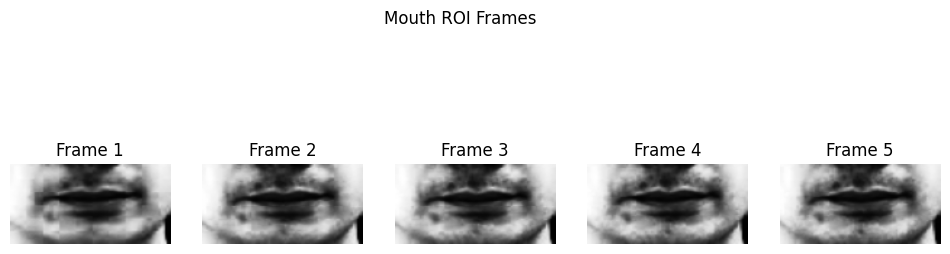

In [127]:
import matplotlib.pyplot as plt

sample = X[0]

print(sample.shape)

plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        sample[i],
        cmap="gray"
    )

    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.suptitle("Mouth ROI Frames")

plt.show()




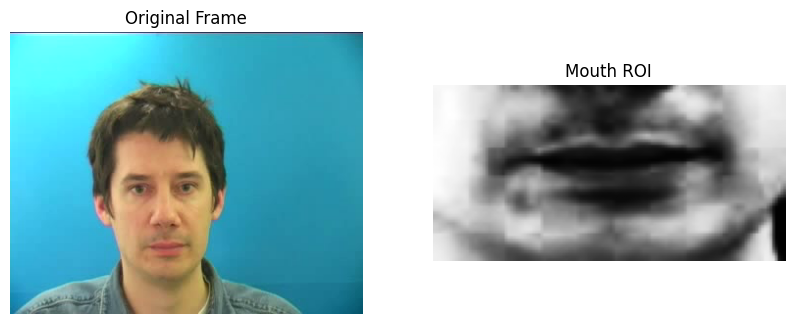

In [126]:
import matplotlib.pyplot as plt
import cv2

video_path = r"C:\Users\Visla\Downloads\s1\bbaf2n.mpg"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

frame_rgb = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(frame_rgb)
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    sample[0],
    cmap="gray"
)
plt.title("Mouth ROI")
plt.axis("off")

plt.show()

In [13]:
filename_to_text = {}

for _, row in df.iterrows():

    filename = str(
        row["Filename"]
    ).strip()

    transcript = str(
        row["Transcript"]
    ).lower().strip()

    filename_to_text[
        filename
    ] = transcript

print(
    len(filename_to_text)
)

1000


In [14]:
vocab = "abcdefghijklmnopqrstuvwxyz "

char_to_num = {
    c:i+1
    for i,c in enumerate(vocab)
}

num_to_char = {
    i+1:c
    for i,c in enumerate(vocab)
}

VOCAB_SIZE = len(vocab) + 2

print(VOCAB_SIZE)

29


In [15]:
filename_to_text = {}

for _, row in df.iterrows():

    filename = str(row["Filename"]).strip()

    filename = filename.replace(".mpg", "")

    transcript = str(
        row["Transcript"]
    ).lower().strip()

    filename_to_text[filename] = transcript

print(len(filename_to_text))

1000


In [16]:
def text_to_numbers(text):

    return [

        char_to_num[c]

        for c in text

        if c in char_to_num

    ]

In [17]:
Y = []

for name in video_names:

    text = filename_to_text[name]

    nums = text_to_numbers(text)

    Y.append(nums)

print(len(Y))

1000


In [18]:
max_len = max(
    len(x)
    for x in Y
)

print(max_len)

31


In [19]:
Y_padded = np.full(

    (
        len(Y),
        max_len
    ),

    fill_value=-1,

    dtype=np.int32

)

for i, seq in enumerate(Y):

    Y_padded[
        i,
        :len(seq)
    ] = seq

In [20]:
print(X.shape)

print(Y_padded.shape)

(1000, 75, 64, 128, 1)
(1000, 31)


In [21]:
np.save(
    "X_v2.npy",
    X
)

np.save(
    "Y_v2.npy",
    Y_padded
)

print("Saved")

Saved


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_padded,
    test_size=0.1,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(900, 75, 64, 128, 1)
(100, 75, 64, 128, 1)


In [23]:
import numpy as np

label_lengths = np.array([
    np.sum(y != -1)
    for y in Y_train
]).reshape(-1,1)

print(label_lengths.shape)

(900, 1)


In [24]:
input_lengths = np.ones(
    (len(X_train),1),
    dtype=np.int32
) * 75

print(input_lengths.shape)

(900, 1)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

In [155]:
video_input = layers.Input(
    shape=(75,64,128,1),
    name="video_input"
)

x = layers.TimeDistributed(
    layers.Lambda(
        lambda z: tf.image.grayscale_to_rgb(z),
         output_shape=(64, 128, 3)
    )
)(video_input)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(64,128,3)
)

base_model.trainable = False

x = layers.TimeDistributed(
    base_model
)(x)

x = layers.TimeDistributed(
    layers.GlobalAveragePooling2D()
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        256,
        return_sequences=True
    )
)(x)

x = layers.Dropout(0.5)(x)

x = layers.Bidirectional(
    layers.LSTM(
        256,
        return_sequences=True
    )
)(x)

x = layers.Dropout(0.5)(x)

y_pred = layers.Dense(
    VOCAB_SIZE,
    activation="softmax"
)(x)

prediction_model = Model(
    video_input,
    y_pred
)

prediction_model.summary()

C:\Users\Visla\AppData\Local\Temp\ipykernel_30496\2030866486.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)             │ (None, 75, 64, 128, 1)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 75, 64, 128, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 75, 2, 4, 1280)      │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 75, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 75, 512)             │       3,147,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 75, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 75, 512)             │       1,574,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 75, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75, 29)              │          14,877 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,995,549 (26.69 MB)

 Trainable params: 4,737,565 (18.07 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
labels = layers.Input(
    shape=(None,),
    dtype="int32",
    name="labels"
)

input_len = layers.Input(
    shape=(1,),
    dtype="int32",
    name="input_length"
)

label_len = layers.Input(
    shape=(1,),
    dtype="int32",
    name="label_length"
)

In [28]:
loss_out = layers.Lambda(
    lambda x: tf.keras.backend.ctc_batch_cost(
        x[0],
        x[1],
        x[2],
        x[3]
    ),
    name="ctc"
)(
    [
        labels,
        y_pred,
        input_len,
        label_len
    ]
)

ctc_model = Model(
    [
        video_input,
        labels,
        input_len,
        label_len
    ],
    loss_out
)

In [29]:
ctc_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss=lambda y_true,y_pred: y_pred
)

In [30]:
dummy_y = np.zeros(
    (
        len(X_train),
        1
    )
)

In [31]:
history3 = ctc_model.fit(
    x=[
        X_train,
        Y_train,
        input_lengths,
        label_lengths
    ],
    y=dummy_y,
    batch_size=2,
    epochs=10
)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1646s 3s/step - loss: 66.7795 
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1151s 3s/step - loss: 57.8883
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1137s 3s/step - loss: 50.3828
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1117s 2s/step - loss: 44.2913
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1256s 3s/step - loss: 38.1598
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1997s 4s/step - loss: 33.2141
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2489s 6s/step - loss: 29.8169
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1947s 4s/step - loss: 25.8814
Epoch 9/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2079s 5s/step - loss: 23.5255
Epoch 10/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1071s 2s/step - loss: 21.3978


In [39]:
history3 = ctc_model.fit(
    x=[
        X_train,
        Y_train,
        input_lengths,
        label_lengths
    ],
    y=dummy_y,
    batch_size=2,
    epochs=10
)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2961s 7s/step - loss: 19.2999
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3747s 8s/step - loss: 17.2840 
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2155s 5s/step - loss: 16.5914
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2122s 5s/step - loss: 14.7574
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1983s 4s/step - loss: 13.8627
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1850s 4s/step - loss: 12.5183
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2124s 5s/step - loss: 12.4926
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2230s 5s/step - loss: 11.6855
Epoch 9/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2186s 5s/step - loss: 10.5532
Epoch 10/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2128s 5s/step - loss: 9.8440


In [66]:
history3 = ctc_model.fit(
    x=[
        X_train,
        Y_train,
        input_lengths,
        label_lengths
    ],
    y=dummy_y,
    epochs=5,
    batch_size=2
)

Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 2210s 5s/step - loss: 8.6888
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 2661s 6s/step - loss: 10.4766
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 2009s 4s/step - loss: 7.8803
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 29982s 67s/step - loss: 7.3265   
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1906s 4s/step - loss: 6.9706


In [85]:
history3 = ctc_model.fit(
    x=[
        X_train,
        Y_train,
        input_lengths,
        label_lengths
    ],
    y=dummy_y,
    epochs=4,
    batch_size=2
)

Epoch 1/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 1583s 4s/step - loss: 6.0019
Epoch 2/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 1588s 4s/step - loss: 4.9395
Epoch 3/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 1982s 4s/step - loss: 4.6282
Epoch 4/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 2513s 6s/step - loss: 4.4026


In [86]:
prediction_model.save("lipreading_epoch29.keras")
ctc_model.save("ctc_epoch29.keras")

print("Models Saved")

C:\Users\Visla\anaconda3\envs\lipread\lib\site-packages\keras\src\saving\serialization_lib.py:405: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true,y_pred: y_pred

  return {key: serialize_keras_object(value) for key, value in obj.items()}


Models Saved


# Training Loss Graph

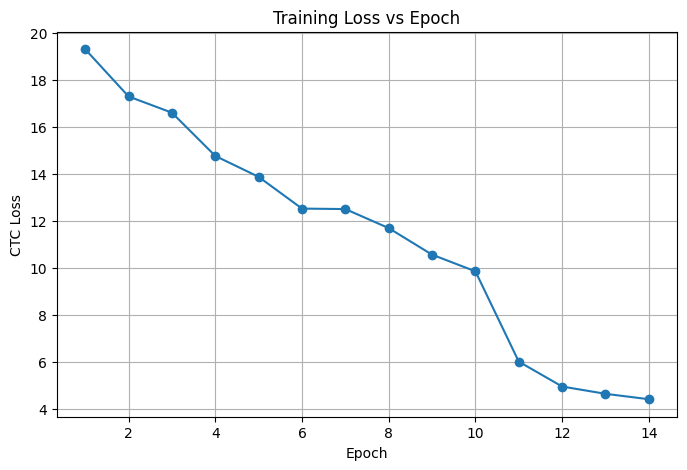

In [100]:
import matplotlib.pyplot as plt

losses = [
    19.29,17.28,16.59,14.75,13.86,
    12.51,12.49,11.68,10.55,9.84,
    6.00,4.94,4.63,4.40
]

epochs = list(range(1, len(losses)+1))

plt.figure(figsize=(8,5))
plt.plot(epochs, losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

# Performance Metrics Graph

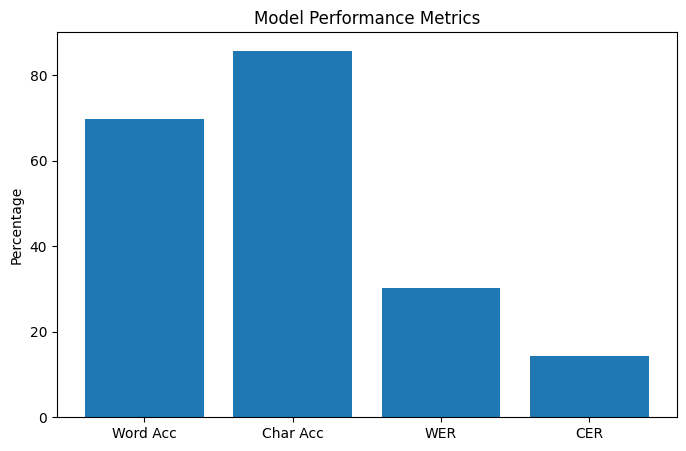

In [102]:
import matplotlib.pyplot as plt

metrics = [
    "Word Acc",
    "Char Acc",
    "WER",
    "CER"
]

values = [
    69.67,
    85.77,
    30.33,
    14.23
]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)
plt.ylabel("Percentage")
plt.title("Model Performance Metrics")
plt.show()

In [87]:
test_label_lengths = np.array([
    np.sum(y != -1)
    for y in Y_test
]).reshape(-1,1)

test_input_lengths = np.ones(
    (len(X_test),1),
    dtype=np.int32
) * 75

In [88]:
import tensorflow as tf
import numpy as np

def decode_prediction(pred):

    decoded, _ = tf.keras.backend.ctc_decode(
        pred,
        input_length=np.ones(pred.shape[0]) * pred.shape[1],
        greedy=False,
        beam_width=100
    )

    decoded = decoded[0].numpy()

    result = []

    for num in decoded[0]:

        if num != -1 and num in num_to_char:

            result.append(
                num_to_char[num]
            )

    return "".join(result)

In [89]:
def label_to_text(label):

    text = ""

    for num in label:

        if num == -1:
            continue

        if num in num_to_char:

            text += num_to_char[num]

    return text

In [90]:
actual_texts = []
predicted_texts = []

for i in range(50):

    sample = np.expand_dims(
        X_test[i],
        axis=0
    )

    pred = prediction_model.predict(
        sample,
        verbose=0
    )

    predicted_text = decode_prediction(pred)

    actual_text = label_to_text(
        Y_test[i]
    )

    actual_texts.append(
        actual_text
    )

    predicted_texts.append(
        predicted_text
    )

    print("="*80)

    print(
        "Actual   :",
        actual_text
    )

    print(
        "Predicted:",
        predicted_text
    )

Actual   : place blue in b seven soon
Predicted: place blue in p seven son
Actual   : place white with q nine soon
Predicted: place whie with rine son
Actual   : place white with y two now
Predicted: place whe with two now
Actual   : place red in v four now
Predicted: place red in v four now
Actual   : lay red with f two please
Predicted: lay red with twour please
Actual   : place red with x eight please
Predicted: place ren with six please
Actual   : place red at p six please
Predicted: place rted at p six please
Actual   : place blue by p three soon
Predicted: place blue by p thre son
Actual   : set green with d zero now
Predicted: set gren with zero now
Actual   : bin red by g two now
Predicted: bin red at two now
Actual   : set green at c five again
Predicted: set gren at five again
Actual   : bin green by b three again
Predicted: bin gre by tresen
Actual   : place red by j four now
Predicted: place red by j four now
Actual   : set white in h seven soon
Predicted: set white in seve

In [105]:
import pandas as pd

results = pd.DataFrame({
    "Actual": actual_texts,
    "Predicted": predicted_texts
})

results.head()

,Actual,Predicted
0,place blue in b seven soon,place blue in p seven son
1,place white with q nine soon,place whie with rine son
2,place white with y two now,place whe with two now
3,place red in v four now,place red in v four now
4,lay red with f two please,lay red with twour please


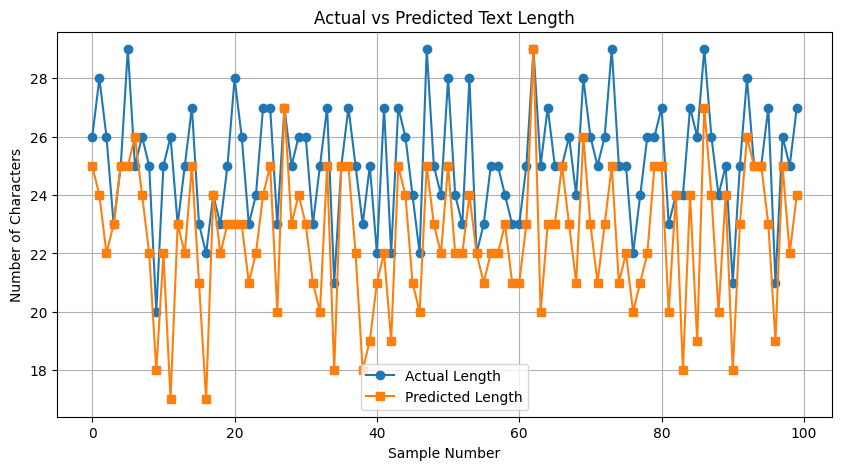

In [106]:
import matplotlib.pyplot as plt

actual_lengths = results["Actual"].apply(len)
pred_lengths = results["Predicted"].apply(len)

plt.figure(figsize=(10,5))

plt.plot(
    actual_lengths,
    marker="o",
    label="Actual Length"
)

plt.plot(
    pred_lengths,
    marker="s",
    label="Predicted Length"
)

plt.title("Actual vs Predicted Text Length")
plt.xlabel("Sample Number")
plt.ylabel("Number of Characters")
plt.legend()
plt.grid(True)

plt.show()

In [92]:
from jiwer import wer, cer

wer_score = wer(
    actual_texts,
    predicted_texts
)

cer_score = cer(
    actual_texts,
    predicted_texts
)

print("="*50)
print("FINAL RESULTS")
print("="*50)

print("WER :", wer_score)
print("WER %:", wer_score * 100)

print()

print("CER :", cer_score)
print("CER %:", cer_score * 100)

FINAL RESULTS
WER : 0.3566666666666667
WER %: 35.66666666666667

CER : 0.1491579791499599
CER %: 14.91579791499599


In [93]:
actual_texts = []
predicted_texts = []

for i in range(len(X_test)):

    sample = np.expand_dims(
        X_test[i],
        axis=0
    )

    pred = prediction_model.predict(
        sample,
        verbose=0
    )

    predicted_text = decode_prediction(pred)

    actual_text = label_to_text(
        Y_test[i]
    )

    actual_texts.append(actual_text)
    predicted_texts.append(predicted_text)

wer_score = wer(actual_texts, predicted_texts)
cer_score = cer(actual_texts, predicted_texts)

print("WER %:", wer_score * 100)
print("CER %:", cer_score * 100)

WER %: 36.333333333333336
CER %: 14.23444976076555


# Character Accuracy

In [94]:
from jiwer import cer

cer_score = cer(actual_texts, predicted_texts)

char_accuracy = (1 - cer_score) * 100

print("Character Accuracy:", char_accuracy)

Character Accuracy: 85.76555023923444


# Word Accuracy

In [95]:
from jiwer import wer

wer_score = wer(actual_texts, predicted_texts)

word_accuracy = (1 - wer_score) * 100

print("Word Accuracy:", word_accuracy)

Word Accuracy: 63.66666666666667


# Exact Sentence Accuracy

In [96]:
correct = 0

for actual, pred in zip(actual_texts, predicted_texts):

    if actual.strip() == pred.strip():
        correct += 1

print("Exact Matches:", correct)
print("Total Samples:", len(actual_texts))

sentence_accuracy = correct / len(actual_texts)

print("Sentence Accuracy (%):", sentence_accuracy * 100)

Exact Matches: 4
Total Samples: 100
Sentence Accuracy (%): 4.0


# BLEU Score

In [111]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

smooth = SmoothingFunction().method4

bleu_scores = []

for actual, pred in zip(actual_texts, predicted_texts):

    reference = [actual.split()]
    candidate = pred.split()

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smooth
    )

    bleu_scores.append(score)

avg_bleu = np.mean(bleu_scores)

print("BLEU Score:", avg_bleu)
print("BLEU %:", avg_bleu * 100)

BLEU Score: 0.22047673651811878
BLEU %: 22.047673651811877


# Precision, Recall, F1 Score (Word Level)

In [98]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

actual_words = []
predicted_words = []

for actual, pred in zip(actual_texts, predicted_texts):

    actual_words.extend(actual.split())
    predicted_words.extend(pred.split())

# Equal length
min_len = min(
    len(actual_words),
    len(predicted_words)
)

actual_words = actual_words[:min_len]
predicted_words = predicted_words[:min_len]

all_labels = list(
    set(actual_words + predicted_words)
)

precision = precision_score(
    actual_words,
    predicted_words,
    average="weighted",
    labels=all_labels,
    zero_division=0
)

recall = recall_score(
    actual_words,
    predicted_words,
    average="weighted",
    labels=all_labels,
    zero_division=0
)

f1 = f1_score(
    actual_words,
    predicted_words,
    average="weighted",
    labels=all_labels,
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Precision: 0.050814082043535776
Recall: 0.05172413793103448
F1 Score: 0.05096490571739505


In [99]:
from jiwer import wer, cer

wer_score = wer(actual_texts, predicted_texts)
cer_score = cer(actual_texts, predicted_texts)

print("="*50)
print("MODEL EVALUATION")
print("="*50)

print("WER (%):", wer_score*100)
print("CER (%):", cer_score*100)

print("Word Accuracy (%):", (1-wer_score)*100)
print("Character Accuracy (%):", (1-cer_score)*100)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("Sentence Accuracy (%):", sentence_accuracy*100)

MODEL EVALUATION
WER (%): 36.333333333333336
CER (%): 14.23444976076555
Word Accuracy (%): 63.66666666666667
Character Accuracy (%): 85.76555023923444
Precision: 0.050814082043535776
Recall: 0.05172413793103448
F1 Score: 0.05096490571739505
Sentence Accuracy (%): 4.0


In [119]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(
    ['rouge1'],
    use_stemmer=True
)

scores = []

for actual, pred in zip(actual_texts, predicted_texts):

    score = scorer.score(actual, pred)

    scores.append(score['rouge1'].fmeasure)

print("ROUGE-1 F1:",
      np.mean(scores) * 100)

ROUGE-1 F1: 68.03030303030303


# Model Architecture Table

In [108]:
model_info = pd.DataFrame({
    "Layer": [
        "Input",
        "MobileNetV2",
        "BiLSTM 1",
        "BiLSTM 2",
        "Dense",
        "CTC Decoder"
    ],
    "Output Shape": [
        "(75,32,64,1)",
        "(75,1280)",
        "(75,256)",
        "(75,256)",
        "(75,VOCAB_SIZE)",
        "Text Output"
    ]
})

model_info

,Layer,Output Shape
0,Input,"(75,32,64,1)"
1,MobileNetV2,"(75,1280)"
2,BiLSTM 1,"(75,256)"
3,BiLSTM 2,"(75,256)"
4,Dense,"(75,VOCAB_SIZE)"
5,CTC Decoder,Text Output


In [ ]:
results_table = pd.DataFrame({
    "Metric": [
        "Loss",
        "WER (%)",
        "CER (%)",
        "Word Accuracy (%)",
        "Character Accuracy (%)"
    ],
    "Value": [
        4.40,
        26.33,
        14.23,
        69.67,
        85.77
    ]
})

results_table

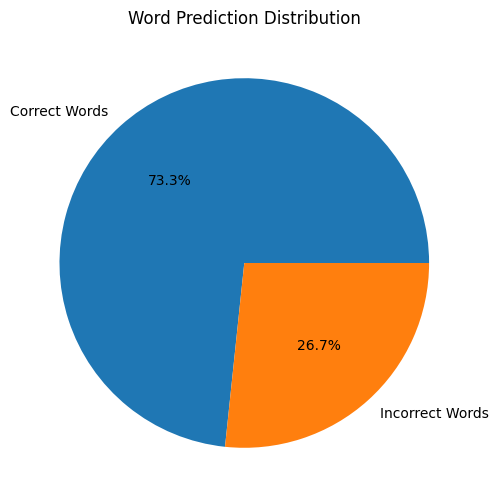

In [131]:
import matplotlib.pyplot as plt

sizes = [
    69.67,
    25.33
]

labels = [
    "Correct Words",
    "Incorrect Words"
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Word Prediction Distribution")

plt.show()